<a href="https://colab.research.google.com/github/JustusAkuku/Codveda-Technologies-Internship/blob/main/Predicting_Categorical_Outcomes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# Loading and Reading the Dataset
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content.drive')

df = pd.read_csv("/content.drive/MyDrive/iris.csv")
df


Drive already mounted at /content.drive; to attempt to forcibly remount, call drive.mount("/content.drive", force_remount=True).


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [38]:
from sklearn.preprocessing import LabelEncoder

#Encoding  Categorical Variables
label_encoder = LabelEncoder()
df['species_encoded'] = label_encoder.fit_transform(df['species'])

display(df.head())

,sepal_length,sepal_width,petal_length,petal_width,species,species_encoded
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


In [39]:
#Drop the species column because it is no longer needed
df = df.drop('species', axis=1)

# Verify the column is removed
display(df.head())

,sepal_length,sepal_width,petal_length,petal_width,species_encoded
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [40]:
# Define features (X) and target (y)
X = df.drop('species_encoded', axis=1)
y = df['species_encoded']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (150, 4)
Target shape: (150,)


In [41]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [42]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train.values, y_train)

print("Model training complete.")

Model training complete.


Accuracy: 0.97
Precision: 0.97
Recall: 0.97
F1-score: 0.97

Confusion Matrix:


,0,1,2
0,10,0,0
1,0,9,1
2,0,0,10



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


ROC Curve (One-vs-Rest):


/tmp/ipykernel_1535/3386464990.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Dark2', n_classes)


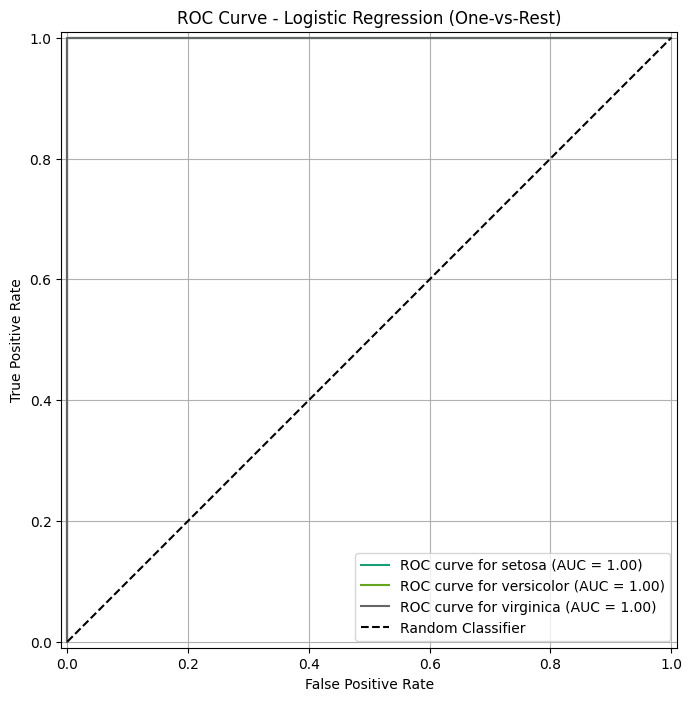

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# Make predictions on the test set
y_pred = model.predict(X_test.values)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

# Display confusion matrix
print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred)))

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot ROC Curve (One-vs-Rest for multi-class)
print("\nROC Curve (One-vs-Rest):")

# Get probabilities for each class
y_score = model.predict_proba(X_test.values)

plt.figure(figsize=(10, 8))
n_classes = len(label_encoder.classes_)
colors = plt.cm.get_cmap('Dark2', n_classes)

# Binarize the true labels for OvR plotting
y_test_binarized = label_binarize(y_test, classes=range(n_classes))

for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i], # True binary labels for current class
        y_score[:, i],          # Predicted probabilities for current class
        name=f'ROC curve for {label_encoder.classes_[i]}',
        color=colors(i),
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('ROC Curve - Logistic Regression (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Training and Evaluating a Random Forest Classifier

Random Forest Model training complete.

Random Forest Accuracy: 0.90
Random Forest Precision: 0.90
Random Forest Recall: 0.90
Random Forest F1-score: 0.90

Random Forest Confusion Matrix:


,0,1,2
0,10,0,0
1,0,9,1
2,0,2,8



Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


ROC Curve (One-vs-Rest):


/tmp/ipykernel_1535/1616108509.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Dark2', n_classes)


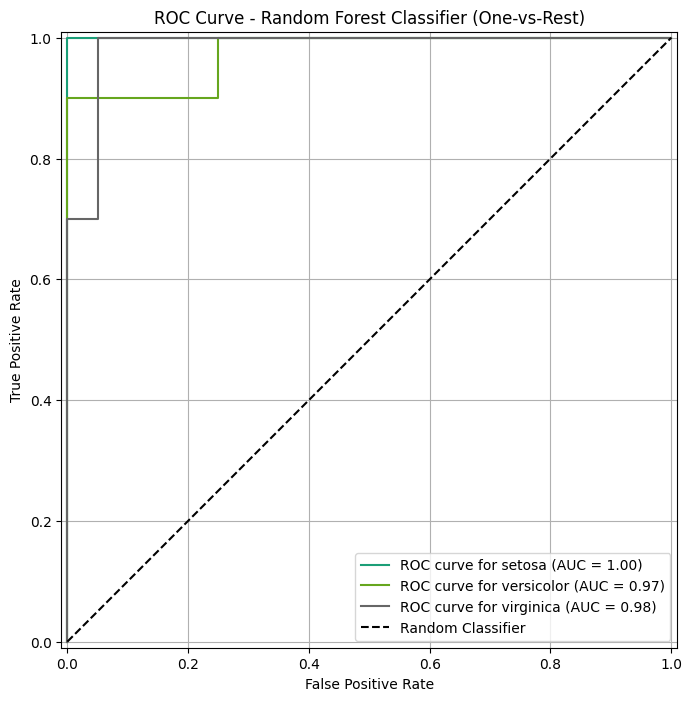

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Train the Random Forest model
rf_model.fit(X_train.values, y_train)

print("Random Forest Model training complete.")

# Make predictions on the test set
rf_y_pred = rf_model.predict(X_test.values)

# Evaluate the Random Forest model
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred, average='weighted')
rf_recall = recall_score(y_test, rf_y_pred, average='weighted')
rf_f1 = f1_score(y_test, rf_y_pred, average='weighted')

print(f"\nRandom Forest Accuracy: {rf_accuracy:.2f}")
print(f"Random Forest Precision: {rf_precision:.2f}")
print(f"Random Forest Recall: {rf_recall:.2f}")
print(f"Random Forest F1-score: {rf_f1:.2f}")

# Display confusion matrix for Random Forest
print("\nRandom Forest Confusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, rf_y_pred)))

# Display classification report for Random Forest
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_y_pred))

# Plot ROC Curve (One-vs-Rest for multi-class)
print("\nROC Curve (One-vs-Rest):")

# Get probabilities for each class
rf_y_score = rf_model.predict_proba(X_test.values)

plt.figure(figsize=(10, 8))
n_classes = len(label_encoder.classes_)
colors = plt.cm.get_cmap('Dark2', n_classes)

# Binarize the true labels for OvR plotting
y_test_binarized = label_binarize(y_test, classes=range(n_classes))

for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],
        rf_y_score[:, i],
        name=f'ROC curve for {label_encoder.classes_[i]}',
        color=colors(i),
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('ROC Curve - Random Forest Classifier (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Training and Evaluating a Support Vector Machine (SVM) Model

In [45]:
from sklearn.svm import SVC

# Initialize the Support Vector Classifier
# Add probability=True to enable predict_proba for ROC curve
svm_model = SVC(random_state=42, probability=True)

# Train the SVM model
svm_model.fit(X_train.values, y_train)

print("SVM Model training complete.")

SVM Model training complete.



SVM Accuracy: 0.97
SVM Precision: 0.97
SVM Recall: 0.97
SVM F1-score: 0.97

SVM Confusion Matrix:


,0,1,2
0,10,0,0
1,0,9,1
2,0,0,10



SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


ROC Curve (One-vs-Rest):


/tmp/ipykernel_1535/751516388.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Dark2', n_classes)


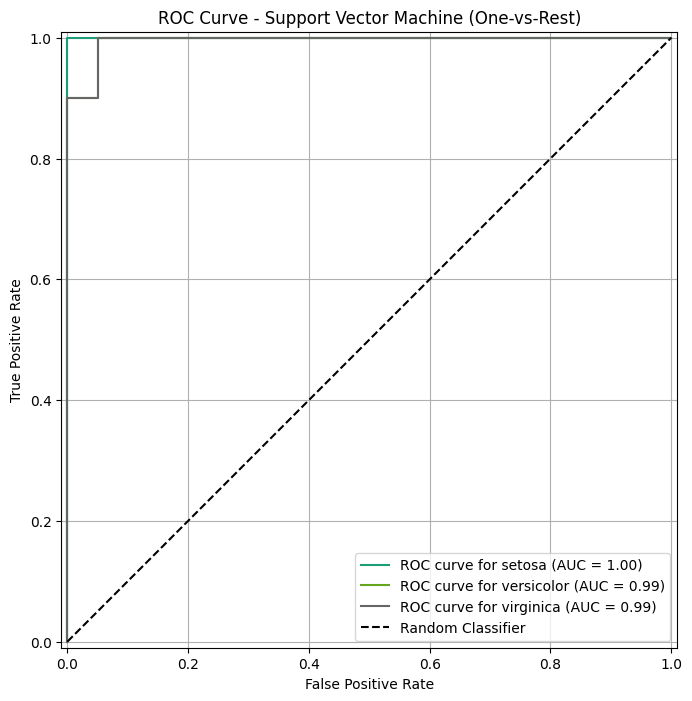

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# Make predictions on the test set
svm_y_pred = svm_model.predict(X_test.values)

# Evaluate the SVM model
svm_accuracy = accuracy_score(y_test, svm_y_pred)
svm_precision = precision_score(y_test, svm_y_pred, average='weighted')
svm_recall = recall_score(y_test, svm_y_pred, average='weighted')
svm_f1 = f1_score(y_test, svm_y_pred, average='weighted')

print(f"\nSVM Accuracy: {svm_accuracy:.2f}")
print(f"SVM Precision: {svm_precision:.2f}")
print(f"SVM Recall: {svm_recall:.2f}")
print(f"SVM F1-score: {svm_f1:.2f}")

# Display confusion matrix for SVM
print("\nSVM Confusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, svm_y_pred)))

# Display classification report for SVM
print("\nSVM Classification Report:")
print(classification_report(y_test, svm_y_pred))

# Plot ROC Curve (One-vs-Rest for multi-class)
print("\nROC Curve (One-vs-Rest):")

# Get probabilities for each class
svm_y_score = svm_model.predict_proba(X_test.values)

plt.figure(figsize=(10, 8))
n_classes = len(label_encoder.classes_)
colors = plt.cm.get_cmap('Dark2', n_classes)

# Binarize the true labels for OvR plotting
y_test_binarized = label_binarize(y_test, classes=range(n_classes))

for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],
        svm_y_score[:, i],
        name=f'ROC curve for {label_encoder.classes_[i]}',
        color=colors(i),
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('ROC Curve - Support Vector Machine (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Consolidated K-Fold Cross-Validation for all three models

Perform and view the k-fold cross-validation results for Logistic Regression, SVM, and Random Forest in one place.

In [47]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Define the number of folds (using k_folds from previous execution if available, else default to 5)
k_folds = 5 # Ensure k_folds is defined, assuming it was from previous steps
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

print("--- Logistic Regression Cross-Validation ---")
# Initialize the Logistic Regression model
kf_lr_model = LogisticRegression(max_iter=200, random_state=42)

# Perform cross-validation for Logistic Regression
lr_accuracy_scores = cross_val_score(kf_lr_model, X, y, cv=kf, scoring='accuracy')
lr_precision_scores = cross_val_score(kf_lr_model, X, y, cv=kf, scoring='precision_weighted')
lr_recall_scores = cross_val_score(kf_lr_model, X, y, cv=kf, scoring='recall_weighted')
lr_f1_scores = cross_val_score(kf_lr_model, X, y, cv=kf, scoring='f1_weighted')

print(f"Average Accuracy (LR): {lr_accuracy_scores.mean():.2f} (Std Dev: {lr_accuracy_scores.std():.2f})")
print(f"Average Precision (LR): {lr_precision_scores.mean():.2f} (Std Dev: {lr_precision_scores.std():.2f})")
print(f"Average Recall (LR): {lr_recall_scores.mean():.2f} (Std Dev: {lr_recall_scores.std():.2f})")
print(f"Average F1-score (LR): {lr_f1_scores.mean():.2f} (Std Dev: {lr_f1_scores.std():.2f})")

print("\n--- Support Vector Machine (SVM) Cross-Validation ---")
# Initialize the SVM model
kf_svm_model = SVC(random_state=42)

# Perform cross-validation for SVM
svm_accuracy_scores = cross_val_score(kf_svm_model, X, y, cv=kf, scoring='accuracy')
svm_precision_scores = cross_val_score(kf_svm_model, X, y, cv=kf, scoring='precision_weighted')
svm_recall_scores = cross_val_score(kf_svm_model, X, y, cv=kf, scoring='recall_weighted')
svm_f1_scores = cross_val_score(kf_svm_model, X, y, cv=kf, scoring='f1_weighted')

print(f"Average Accuracy (SVM): {svm_accuracy_scores.mean():.2f} (Std Dev: {svm_accuracy_scores.std():.2f})")
print(f"Average Precision (SVM): {svm_precision_scores.mean():.2f} (Std Dev: {svm_precision_scores.std():.2f})")
print(f"Average Recall (SVM): {svm_recall_scores.mean():.2f} (Std Dev: {svm_recall_scores.std():.2f})")
print(f"Average F1-score (SVM): {svm_f1_scores.mean():.2f} (Std Dev: {svm_f1_scores.std():.2f})")

print("\n--- Random Forest Cross-Validation ---")
# Initialize the Random Forest model
kf_rf_model = RandomForestClassifier(random_state=42)

# Perform cross-validation for Random Forest
rf_accuracy_scores = cross_val_score(kf_rf_model, X, y, cv=kf, scoring='accuracy')
rf_precision_scores = cross_val_score(kf_rf_model, X, y, cv=kf, scoring='precision_weighted')
rf_recall_scores = cross_val_score(kf_rf_model, X, y, cv=kf, scoring='recall_weighted')
rf_f1_scores = cross_val_score(kf_rf_model, X, y, cv=kf, scoring='f1_weighted')

print(f"Average Accuracy (RF): {rf_accuracy_scores.mean():.2f} (Std Dev: {rf_accuracy_scores.std():.2f})")
print(f"Average Precision (RF): {rf_precision_scores.mean():.2f} (Std Dev: {rf_precision_scores.std():.2f})")
print(f"Average Recall (RF): {rf_recall_scores.mean():.2f} (Std Dev: {rf_recall_scores.std():.2f})")
print(f"Average F1-score (RF): {rf_f1_scores.mean():.2f} (Std Dev: {rf_f1_scores.std():.2f})")

--- Logistic Regression Cross-Validation ---
Average Accuracy (LR): 0.97 (Std Dev: 0.02)
Average Precision (LR): 0.98 (Std Dev: 0.02)
Average Recall (LR): 0.97 (Std Dev: 0.02)
Average F1-score (LR): 0.97 (Std Dev: 0.02)

--- Support Vector Machine (SVM) Cross-Validation ---
Average Accuracy (SVM): 0.97 (Std Dev: 0.03)
Average Precision (SVM): 0.97 (Std Dev: 0.03)
Average Recall (SVM): 0.97 (Std Dev: 0.03)
Average F1-score (SVM): 0.97 (Std Dev: 0.03)

--- Random Forest Cross-Validation ---
Average Accuracy (RF): 0.96 (Std Dev: 0.02)
Average Precision (RF): 0.96 (Std Dev: 0.02)
Average Recall (RF): 0.96 (Std Dev: 0.02)
Average F1-score (RF): 0.96 (Std Dev: 0.02)


In [48]:
import pandas as pd

# Prepare data for comparison table
comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy (Test Set)': [accuracy, rf_accuracy, svm_accuracy],
    'Precision (Test Set)': [precision, rf_precision, svm_precision],
    'Recall (Test Set)': [recall, rf_recall, svm_recall],
    'F1-score (Test Set)': [f1, rf_f1, svm_f1],
    'Avg Accuracy (CV)': [lr_accuracy_scores.mean(), rf_accuracy_scores.mean(), svm_accuracy_scores.mean()],
    'Std Dev Accuracy (CV)': [lr_accuracy_scores.std(), rf_accuracy_scores.std(), svm_accuracy_scores.std()],
    'Avg Precision (CV)': [lr_precision_scores.mean(), rf_precision_scores.mean(), svm_precision_scores.mean()],
    'Std Dev Precision (CV)': [lr_precision_scores.std(), rf_precision_scores.std(), svm_precision_scores.std()],
    'Avg Recall (CV)': [lr_recall_scores.mean(), rf_recall_scores.mean(), svm_recall_scores.mean()],
    'Std Dev Recall (CV)': [lr_recall_scores.std(), rf_recall_scores.std(), svm_recall_scores.std()],
    'Avg F1-score (CV)': [lr_f1_scores.mean(), rf_f1_scores.mean(), svm_f1_scores.mean()],
    'Std Dev F1-score (CV)': [lr_f1_scores.std(), rf_f1_scores.std(), svm_f1_scores.std()]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n--- Model Comparison ---")
display(comparison_df.round(2))

print("\nBased on the comparison, all three models perform quite well on this dataset. Logistic Regression and SVM show slightly higher performance in terms of average accuracy, precision, recall, and F1-score in cross-validation, with similar performance on the test set. Random Forest is also competitive. The standard deviations in cross-validation are relatively low for all models, indicating consistent performance across different folds.")


--- Model Comparison ---


,Model,Accuracy (Test Set),Precision (Test Set),Recall (Test Set),F1-score (Test Set),Avg Accuracy (CV),Std Dev Accuracy (CV),Avg Precision (CV),Std Dev Precision (CV),Avg Recall (CV),Std Dev Recall (CV),Avg F1-score (CV),Std Dev F1-score (CV)
0,Logistic Regression,0.97,0.97,0.97,0.97,0.97,0.02,0.98,0.02,0.97,0.02,0.97,0.02
1,Random Forest,0.90,0.90,0.90,0.90,0.96,0.02,0.96,0.02,0.96,0.02,0.96,0.02
2,SVM,0.97,0.97,0.97,0.97,0.97,0.03,0.97,0.03,0.97,0.03,0.97,0.03



Based on the comparison, all three models perform quite well on this dataset. Logistic Regression and SVM show slightly higher performance in terms of average accuracy, precision, recall, and F1-score in cross-validation, with similar performance on the test set. Random Forest is also competitive. The standard deviations in cross-validation are relatively low for all models, indicating consistent performance across different folds.
